# RQ1: What Key Factors Lead to Late Deliveries, and How Can We Proactively Identify High-Risk Orders to Improve Customer Satisfaction?

## Importing Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, recall_score, precision_recall_curve

## Importing Dataset

In [2]:
data = pd.read_csv("../data/cleaned/cleaned_dataset.csv")

data.head()

,order_id,order_item_id,order_status,order_purchase_timestamp,order_approved_at,order_estimated_delivery_date,is_canceled,customer_id,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume,review_id,review_score,delivered_late,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,1.0,delivered,2017-10-02,2017-10-02,2017-10-18,False,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,1976.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,False,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,1.0,delivered,2018-07-24,2018-07-26,2018-08-13,False,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,4693.0,8d5266042046a06655c8db133d120ba5,4.0,False,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,1.0,delivered,2018-08-08,2018-08-08,2018-09-04,False,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,9576.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,False,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,1.0,delivered,2017-11-18,2017-11-18,2017-12-15,False,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,...,3.0,450.0,30.0,10.0,20.0,6000.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,False,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,1.0,delivered,2018-02-13,2018-02-13,2018-02-26,False,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,4.0,250.0,51.0,15.0,15.0,11475.0,e50934924e227544ba8246aeb3770dd4,5.0,False,-10.0


In [3]:
data.columns

Index(['order_id', 'order_item_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_estimated_delivery_date', 'is_canceled',
       'customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'customer_lat', 'customer_lng',
       'order_delivered_customer_date', 'is_first_time_buyer', 'seller_id',
       'seller_zip_code_prefix', 'seller_city', 'seller_state', 'seller_lat',
       'seller_lng', 'shipping_limit_date', 'order_delivered_carrier_date',
       'handoff_delay', 'distance_km', 'product_id',
       'product_category_name_english', 'price', 'freight_value',
       'product_name_length', 'product_description_length',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'product_volume', 'review_id',
       'review_score', 'delivered_late', 'delivery_delay'],
      dtype='object')

## Pre-Processing

### Removing Unnecessary Columns

In [4]:
data.drop(columns=['order_id', 
                   'order_item_id', 
                   'order_status', 
                   'order_purchase_timestamp', 
                   'order_approved_at',
                   'order_estimated_delivery_date',
                   'is_canceled',
                   'customer_id',
                   'customer_unique_id',
                   'customer_zip_code_prefix',
                   'customer_state',
                   'customer_lat',
                   'customer_lng',
                   'order_delivered_customer_date',
                   'is_first_time_buyer',
                   'seller_zip_code_prefix',
                   'seller_state',
                   'seller_lat',
                   'seller_lng',
                   'shipping_limit_date',
                   'order_delivered_carrier_date',
                   'price',
                   'freight_value',
                   'product_name_length',
                   'product_description_length',
                   'product_photos_qty',
                   'review_id',
                   'review_score',
                   'product_id',
                   'delivery_delay'], inplace=True)

display(data.head())

display(data.shape)

,customer_city,seller_id,seller_city,handoff_delay,distance_km,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume,delivered_late
0,sao paulo,3504c0cb71d7fa48d967e0e4c94d59d9,maua,-2.0,18.576110,housewares,500.0,19.0,8.0,13.0,1976.0,False
1,barreiras,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,-4.0,851.495069,perfumery,400.0,19.0,13.0,19.0,4693.0,False
2,vianopolis,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,-5.0,514.410666,auto,420.0,24.0,19.0,21.0,9576.0,False
3,sao goncalo do amarante,66922902710d126a0e7d26b0e3805106,belo horizonte,-1.0,1822.226336,pet_shop,450.0,30.0,10.0,20.0,6000.0,False
4,santo andre,2c9e548be18521d1c43cde1c582c6de8,mogi das cruzes,-5.0,29.676625,stationery,250.0,51.0,15.0,15.0,11475.0,False


(111717, 12)

### Removing NA Rows

In [5]:
data = data.dropna()

display(data.shape)

(108983, 12)

### Variable Selection

In [6]:
X = data.drop(columns=['delivered_late'])
y = data['delivered_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Encoding Variables

In [7]:
categorical_features = ['customer_city',
                        'seller_city', 
                        'seller_id',
                        'product_category_name_english']

numerical_features = ['handoff_delay', 'distance_km', 'product_weight_g',
                      'product_length_cm', 'product_height_cm',
                      'product_width_cm', 'product_volume']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

# Transform
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

### Getting Feature Names

In [8]:
if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()
    X_test_encoded = X_test_encoded.toarray()

# Get column names
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(cat_feature_names) + numerical_features

# Convert to DataFrames
X_train_df = pd.DataFrame(X_train_encoded, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_encoded, columns=all_feature_names)

### Applying SMOTE

In [9]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_df, y_train)

### Applying StratifiedKFold

In [10]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Focusing Recall for the Positive Late Deliveries

In [11]:
recall_scorer = make_scorer(recall_score, pos_label=True)

## Logistic Regression

### Creating the Best Model

In [12]:
# Logistic regression model
log_reg = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# Hyperparameter grid (penalty type and C values)
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']  # Try both L1 and L2 regularization
}

# Grid search setup
grid_log_reg = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=stratified_cv,
    verbose=2,
    n_jobs=1
)

# Fit model
grid_log_reg.fit(X_train_resampled, y_train_resampled)

# Extract best model and params
best_log_reg = grid_log_reg.best_estimator_
print("Best Parameters:", grid_log_reg.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .................................C=0.01, penalty=l1; total time= 1.1min
[CV] END .................................C=0.01, penalty=l1; total time= 1.2min
[CV] END .................................C=0.01, penalty=l1; total time= 1.2min
[CV] END .................................C=0.01, penalty=l1; total time= 1.0min
[CV] END .................................C=0.01, penalty=l1; total time= 1.0min
[CV] END .................................C=0.01, penalty=l2; total time= 1.0min
[CV] END .................................C=0.01, penalty=l2; total time=  59.8s
[CV] END .................................C=0.01, penalty=l2; total time= 1.0min
[CV] END .................................C=0.01, penalty=l2; total time= 1.1min
[CV] END .................................C=0.01, penalty=l2; total time= 1.0min
[CV] END ..................................C=0.1, penalty=l1; total time=  59.2s
[CV] END ..................................C=0.1,

### Testing the Model


🔍 Optimal Threshold (LogReg): 0.5074

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

       False       0.96      0.77      0.86     20393
        True       0.15      0.59      0.24      1404

    accuracy                           0.76     21797
   macro avg       0.56      0.68      0.55     21797
weighted avg       0.91      0.76      0.82     21797

ROC-AUC Score: 0.7257


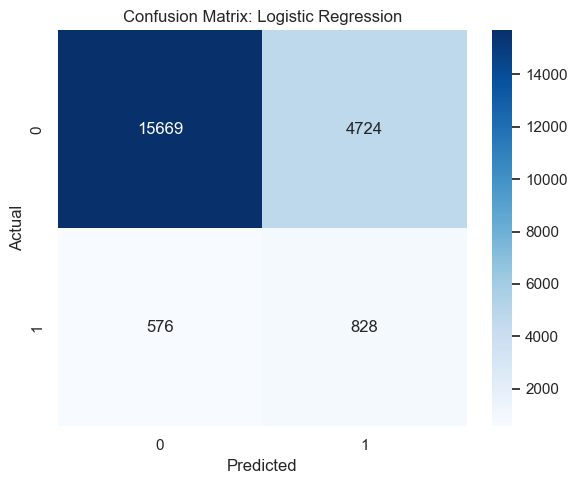

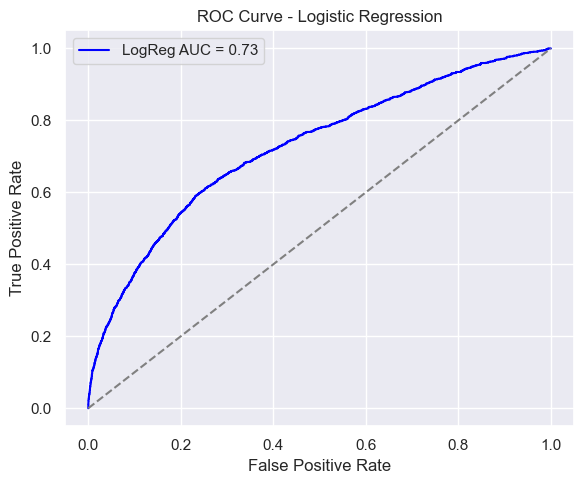

In [ ]:
# Predict probabilities
y_proba_logreg = best_log_reg.predict_proba(X_test_df)[:, 1]

# === Threshold Optimization ===
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_logreg)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-6)
optimal_threshold_logreg = thresholds[np.argmax(f2_scores)]
print(f"\nOptimal Threshold (LogReg): {optimal_threshold_logreg:.4f}")

# Apply optimal threshold
y_pred_logreg_opt = (y_proba_logreg >= optimal_threshold_logreg).astype(int)

# Metrics
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_logreg_opt))

roc_auc = roc_auc_score(y_test, y_proba_logreg)
print(f"ROC-AUC Score: {roc_auc:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_logreg_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"LogReg AUC = {roc_auc:.2f}", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

## Decision Tree

### Creating the Best Model

In [14]:
# Define the Decision Tree Classifier
tree_clf = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
param_grid_tree = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20],
    'criterion': ['gini', 'entropy']
}

# Grid search
grid_tree = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid_tree,
    scoring=recall_scorer,
    cv=stratified_cv,
    verbose=2,
    n_jobs=1
)

# Fit to the resampled training set
grid_tree.fit(X_train_resampled, y_train_resampled)

# Best model and parameters
best_tree = grid_tree.best_estimator_
print("Best Parameters:", grid_tree.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time= 1.1min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  58.0s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time= 1.0min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time= 1.0min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=10; total time=  59.4s
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time= 1.0min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time= 1.0min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time= 1.1min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time= 1.1min
[CV] END ..criterion=gini, max_depth=5, min_samples_split=20; total time= 1.0min
[CV] END .criterion=gini, max_depth=10, min_samples_split=10; total time= 1.1min
[CV] END .criterion=gini, max_depth=10, min_samp

### Evaluting the Model


Optimal Threshold (Decision Tree): 0.1355

Classification Report (Decision Tree):
              precision    recall  f1-score   support

       False       0.97      0.40      0.56     20393
        True       0.08      0.80      0.15      1404

    accuracy                           0.42     21797
   macro avg       0.53      0.60      0.36     21797
weighted avg       0.91      0.42      0.54     21797

ROC-AUC Score (Tree): 0.6511


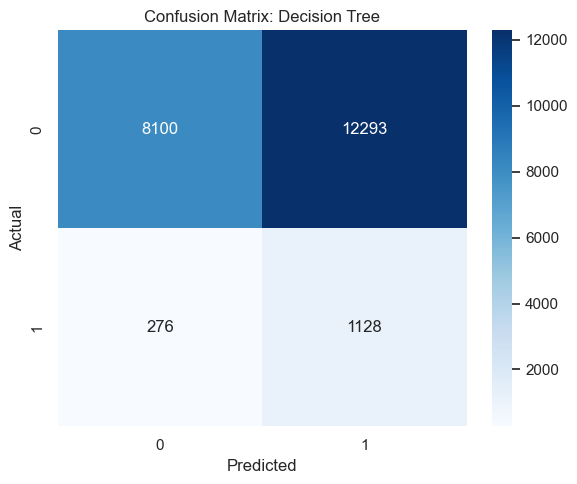

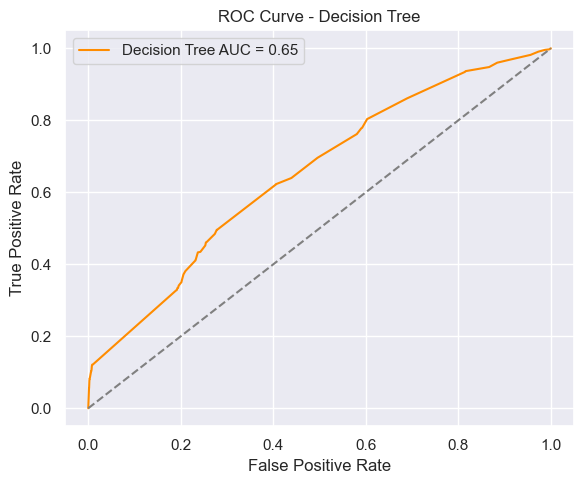

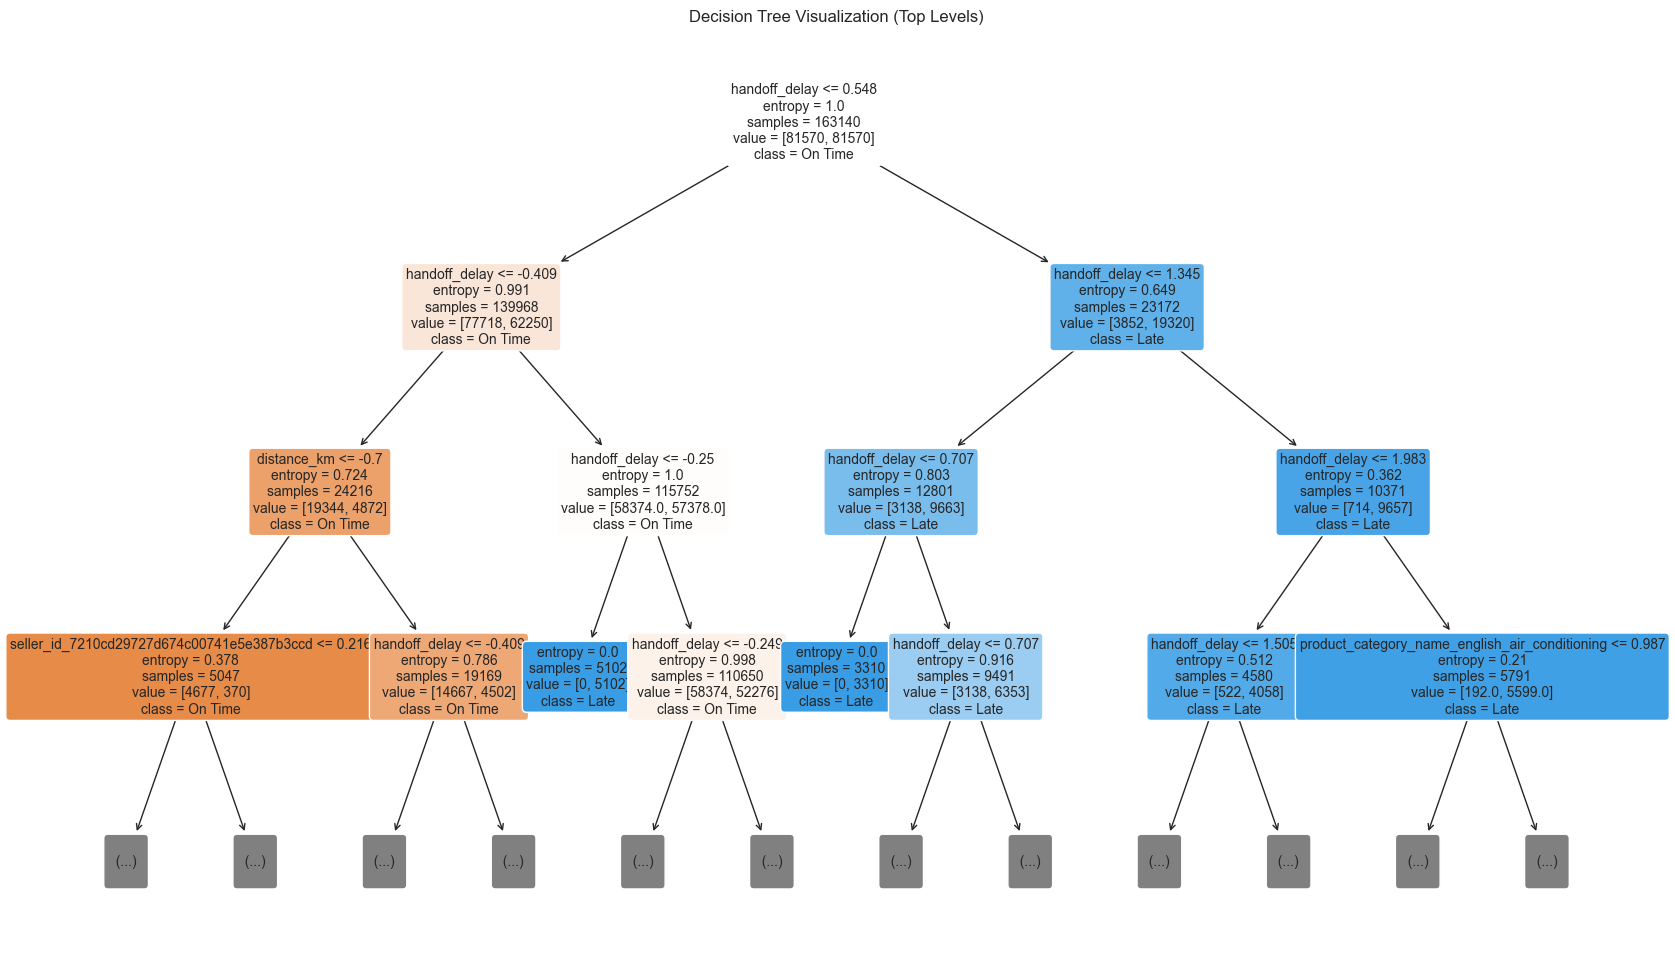

In [17]:
# Predict probabilities
y_proba_tree = best_tree.predict_proba(X_test_df)[:, 1]

# === Threshold Optimization ===
precision_tree, recall_tree, thresholds_tree = precision_recall_curve(y_test, y_proba_tree)
f2_scores_tree = 5 * (precision_tree * recall_tree) / (4 * precision_tree + recall_tree + 1e-6)
optimal_threshold_tree = thresholds_tree[np.argmax(f2_scores_tree)]
print(f"\nOptimal Threshold (Decision Tree): {optimal_threshold_tree:.4f}")

# Apply optimal threshold
y_pred_tree_opt = (y_proba_tree >= optimal_threshold_tree).astype(int)

# Metrics
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_tree_opt))

roc_auc_tree = roc_auc_score(y_test, y_proba_tree)
print(f"ROC-AUC Score (Tree): {roc_auc_tree:.4f}")

# Visualizing Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_tree_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)
plt.figure(figsize=(6, 5))
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree AUC = {roc_auc_tree:.2f}", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Visualizing the Decision Tree
plt.figure(figsize=(20, 12))
plot_tree(
    best_tree, 
    feature_names=all_feature_names, 
    class_names=['On Time', 'Late'], 
    filled=True, 
    rounded=True, 
    fontsize=10,
    max_depth=3  # limit depth for readability, remove or increase to see more
)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

## Random Forest

### Creating the Best Model

In [19]:
# Random Forest
rf_clf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [10, 20],
    'class_weight': ['balanced']  # Helps handle imbalance without SMOTE here, but still okay if you keep SMOTE
}

grid_rf = GridSearchCV(
                        estimator=rf_clf, 
                        param_grid=param_grid_rf,
                        scoring=recall_scorer, 
                        cv=stratified_cv, 
                        verbose=2, 
                        n_jobs=1
                    )

grid_rf.fit(X_train_resampled, y_train_resampled)
best_rf = grid_rf.best_estimator_
print("Best Parameters (Random Forest):", grid_rf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time= 1.5min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time= 1.4min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time= 1.7min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time= 1.3min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=100; total time= 1.3min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time= 1.9min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time= 2.0min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time= 1.8min
[CV] END class_weight=balanced, max_depth=10, min_samples_split=10, n_estimators=200; total time= 1.

### Evaluating the Model


Optimal Threshold (Random Forest): 0.4846

Classification Report (Random Forest):
              precision    recall  f1-score   support

       False       0.97      0.67      0.79     20393
        True       0.12      0.65      0.20      1404

    accuracy                           0.67     21797
   macro avg       0.54      0.66      0.50     21797
weighted avg       0.91      0.67      0.75     21797

ROC-AUC Score (Random Forest): 0.7067


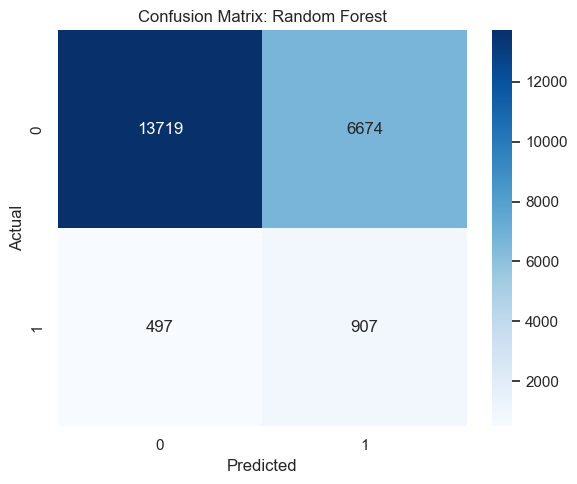

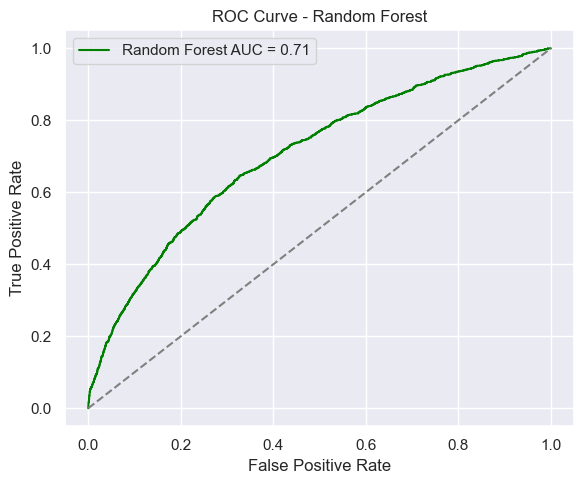

In [20]:
# Predict probabilities
y_proba_rf = best_rf.predict_proba(X_test_df)[:, 1]

# === Threshold Optimization ===
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)
f2_scores_rf = 5 * (precision_rf * recall_rf) / (4 * precision_rf + recall_rf + 1e-6)
optimal_threshold_rf = thresholds_rf[np.argmax(f2_scores_rf)]
print(f"\nOptimal Threshold (Random Forest): {optimal_threshold_rf:.4f}")

# Apply optimal threshold
y_pred_rf_opt = (y_proba_rf >= optimal_threshold_rf).astype(int)

# Metrics
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf_opt))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC Score (Random Forest): {roc_auc_rf:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_opt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_rf:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()